# Statistical analysis of lop algorithms implementation

## setup

In [1]:
!uv sync


Resolved 15 packages in 1ms
Audited 13 packages in 0.01ms


In [2]:
import ast
import itertools
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon


In [3]:
PATH_TO_OUT = Path("data/output")
PATH_TO_IN = Path("data/input")

PATH_TO_BEST_KNOWN = PATH_TO_IN / "best_known.txt"
PATH_TO_INSTANCES = PATH_TO_IN / "instances"
PATH_TO_OUTPUT_IT_IMP = PATH_TO_OUT / "it_im_results.csv"
PATH_TO_OUTPUT_VND = PATH_TO_OUT / "lop_vnd_results.csv"

PATH_TO_FIGS = PATH_TO_OUT / "figs/"

PATH_BENCHMARK = Path("tools/benchmark_best_known.py")


#benchmark parameters
N_WORKERS = 0
N_RUNS = 1

Search and compute raw measurement results of lop benchmark if not founds

In [4]:
if not PATH_TO_OUTPUT_IT_IMP.exists() or not PATH_TO_OUTPUT_VND.exists():
    if not PATH_BENCHMARK.exists():
        raise FileNotFoundError(f"Benchmark script not found: {PATH_BENCHMARK}")

    cmd = [
        "uv",
        "run",
        str(PATH_BENCHMARK),
        "--instances-dir",
        str(PATH_TO_INSTANCES),
        "--best_known_file",
        str(PATH_TO_BEST_KNOWN),
        "--output_it_imp",
        str(PATH_TO_OUTPUT_IT_IMP),
        "--output_vnd",
        str(PATH_TO_OUTPUT_VND),
        "--k",
        str(N_RUNS),
        "-w",
        str(N_WORKERS),
    ]
    exit_code = subprocess.call(cmd)
    if exit_code != 0:
        raise RuntimeError("Benchmark data could not be generated.")


In [5]:
RESULT_COLUMNS = [
    "instance",
    "best_known_cost",
    "sol_start",
    "pivot",
    "neighborhoods",
    "cost",
    "time_s",
]


def parse_neighborhoods(value: str) -> tuple[str, ...]:
    parsed = ast.literal_eval(value)
    if not isinstance(parsed, (list, tuple)):
        raise ValueError(f"Invalid neighborhoods value: {value}")
    return tuple(str(item) for item in parsed)


def load_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=RESULT_COLUMNS).copy()
    df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
    df["gap_pct"] = (df["best_known_cost"] - df["cost"]) / df["best_known_cost"] * 100.0
    return df


df_raw = pd.concat(
    [load_results(PATH_TO_OUTPUT_IT_IMP), load_results(PATH_TO_OUTPUT_VND)],
    ignore_index=True,
)

df_it_imp = df_raw[df_raw["neighborhood_list"].str.len() == 1].copy()
df_vnd = df_raw[df_raw["neighborhood_list"].str.len() > 1].copy()

df_it_imp["neighborhood"] = df_it_imp["neighborhood_list"].str[0]
df_it_imp["algorithm"] = (
    df_it_imp["sol_start"] + " | " + df_it_imp["pivot"] + " | " + df_it_imp["neighborhood"]
)
df_vnd["algorithm"] = df_vnd["neighborhood_list"].map(lambda n: " -> ".join(n))

print(f"Iterative improvement results: {len(df_it_imp)} rows")
print(f"VND results: {len(df_vnd)} rows")
print(df_it_imp)
print(df_vnd)


Iterative improvement results: 936 rows
VND results: 156 rows
           instance  best_known_cost sol_start  pivot  neighborhoods     cost  \
0     N-be75eec_150          3482828    random  first  ['transpose']    54581   
1     N-be75eec_150          3482828   c_and_w  first  ['transpose']    59319   
2     N-be75eec_150          3482828    random  first   ['exchange']  1320189   
3     N-be75eec_150          3482828   c_and_w  first   ['exchange']   777059   
4     N-be75eec_150          3482828    random  first     ['insert']  1247636   
..              ...              ...       ...    ...            ...      ...   
931  N-tiw56r72_250          7451579   c_and_w   best  ['transpose']    60802   
932  N-tiw56r72_250          7451579    random   best   ['exchange']  2074005   
933  N-tiw56r72_250          7451579   c_and_w   best   ['exchange']  1263172   
934  N-tiw56r72_250          7451579    random   best     ['insert']  2098181   
935  N-tiw56r72_250          7451579   c_and_w 

In [6]:
it_summary = (
    df_it_imp.groupby(["sol_start", "pivot", "neighborhood", "algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values(["avg_gap_pct", "total_time_s"], ignore_index=True)
)

vnd_summary = (
    df_vnd.groupby(["algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values("avg_gap_pct", ignore_index=True)
)

it_summary.to_csv(PATH_TO_OUT / "it_im_summary_stats.csv", index=False)
vnd_summary.to_csv(PATH_TO_OUT / "vnd_summary_stats.csv", index=False)

display(it_summary)
display(vnd_summary)


,sol_start,pivot,neighborhood,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,random,first,exchange,random | first | exchange,67.140506,3.909041,1498.703240
1,random,best,insert,random | best | insert,67.835550,3.868568,910.331140
2,random,best,exchange,random | best | exchange,67.942112,3.976425,251.670706
3,random,first,insert,random | first | insert,68.396039,3.957575,932.522400
4,c_and_w,first,exchange,c_and_w | first | exchange,79.760038,2.238394,1283.537560
5,c_and_w,best,insert,c_and_w | best | insert,80.215386,2.195691,857.508780
6,c_and_w,best,exchange,c_and_w | best | exchange,80.713905,2.206824,239.575922
7,c_and_w,first,insert,c_and_w | first | insert,81.088979,2.189705,967.405200
8,random,best,transpose,random | best | transpose,98.451792,0.697603,1.455662
9,random,first,transpose,random | first | transpose,98.564876,0.844019,1.189224


,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,transpose -> exchange -> insert,79.409889,2.283542,1453.60935
1,transpose -> insert -> exchange,80.597522,2.257596,1150.85271


In [7]:
def run_pairwise_tests(gap_matrix: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for left, right in itertools.combinations(gap_matrix.columns, 2):
        paired = gap_matrix[[left, right]].dropna()
        if paired.empty:
            continue

        left_values = paired[left].to_numpy()
        right_values = paired[right].to_numpy()

        t_stat, t_p_value = ttest_rel(left_values, right_values, alternative="two-sided")

        diff = left_values - right_values
        if np.allclose(diff, 0.0):
            w_stat, w_p_value = 0.0, 1.0
        else:
            w_stat, w_p_value = wilcoxon(
                left_values,
                right_values,
                alternative="two-sided",
                zero_method="wilcox",
            )

        rows.append(
            {
                "algorithm_a": left,
                "algorithm_b": right,
                "n_instances": len(paired),
                "mean_gap_a": left_values.mean(),
                "mean_gap_b": right_values.mean(),
                "ttest_p_value": t_p_value,
                "wilcoxon_p_value": w_p_value,
                "significant_5pct_wilcoxon": w_p_value < 0.05,
            }
        )

    return pd.DataFrame(rows).sort_values("wilcoxon_p_value", ignore_index=True)


it_gap_matrix = df_it_imp.pivot(index="instance", columns="algorithm", values="gap_pct")
it_pairwise_tests = run_pairwise_tests(it_gap_matrix)
it_pairwise_tests.to_csv(PATH_TO_OUT / "it_im_pairwise_tests.csv", index=False)

vnd_gap_matrix = df_vnd.pivot(index="instance", columns="algorithm", values="gap_pct")
if vnd_gap_matrix.shape[1] != 2:
    raise ValueError(f"Expected exactly 2 VND algorithms, got {vnd_gap_matrix.shape[1]}")

vnd_a, vnd_b = vnd_gap_matrix.columns
vnd_paired = vnd_gap_matrix[[vnd_a, vnd_b]].dropna()

vnd_t_stat, vnd_t_p_value = ttest_rel(vnd_paired[vnd_a], vnd_paired[vnd_b], alternative="two-sided")
vnd_diff = vnd_paired[vnd_a].to_numpy() - vnd_paired[vnd_b].to_numpy()
if np.allclose(vnd_diff, 0.0):
    vnd_w_stat, vnd_w_p_value = 0.0, 1.0
else:
    vnd_w_stat, vnd_w_p_value = wilcoxon(
        vnd_paired[vnd_a],
        vnd_paired[vnd_b],
        alternative="two-sided",
        zero_method="wilcox",
    )

vnd_test = pd.DataFrame(
    [
        {
            "algorithm_a": vnd_a,
            "algorithm_b": vnd_b,
            "n_instances": len(vnd_paired),
            "mean_gap_a": vnd_paired[vnd_a].mean(),
            "mean_gap_b": vnd_paired[vnd_b].mean(),
            "ttest_p_value": vnd_t_p_value,
            "wilcoxon_p_value": vnd_w_p_value,
            "significant_5pct_wilcoxon": vnd_w_p_value < 0.05,
        }
    ]
)

vnd_test.to_csv(PATH_TO_OUT / "vnd_stat_test.csv", index=False)

display(it_pairwise_tests.head(20))
display(vnd_test)


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,c_and_w | best | exchange,c_and_w | best | transpose,78,80.713905,98.718895,2.740434e-72,1.682175e-14,True
1,c_and_w | best | exchange,random | best | insert,78,80.713905,67.835550,7.587933e-42,1.682175e-14,True
2,c_and_w | best | exchange,random | best | exchange,78,80.713905,67.942112,1.461313e-40,1.682175e-14,True
3,c_and_w | best | exchange,c_and_w | first | transpose,78,80.713905,98.809398,1.416243e-72,1.682175e-14,True
4,c_and_w | best | exchange,random | best | transpose,78,80.713905,98.451792,1.517589e-70,1.682175e-14,True
5,c_and_w | best | exchange,random | first | transpose,78,80.713905,98.564876,8.920280e-71,1.682175e-14,True
6,c_and_w | best | exchange,random | first | insert,78,80.713905,68.396039,3.674484e-39,1.682175e-14,True
7,c_and_w | best | exchange,random | first | exchange,78,80.713905,67.140506,5.973945e-43,1.682175e-14,True
8,c_and_w | best | insert,random | best | exchange,78,80.215386,67.942112,1.551200e-39,1.682175e-14,True
9,c_and_w | best | insert,c_and_w | first | transpose,78,80.215386,98.809398,4.580310e-74,1.682175e-14,True


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,transpose -> exchange -> insert,transpose -> insert -> exchange,78,79.409889,80.597522,1.217030e-24,3.371464e-14,True


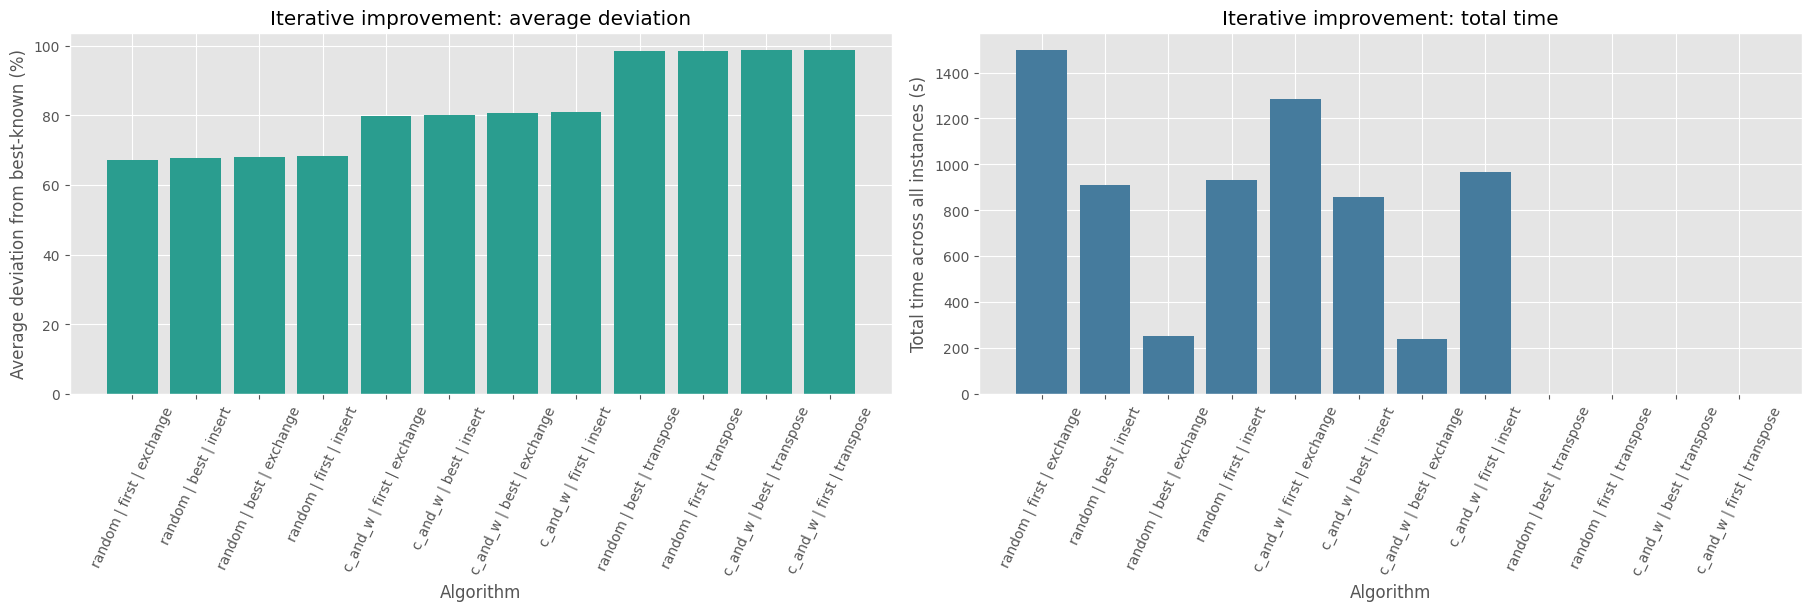

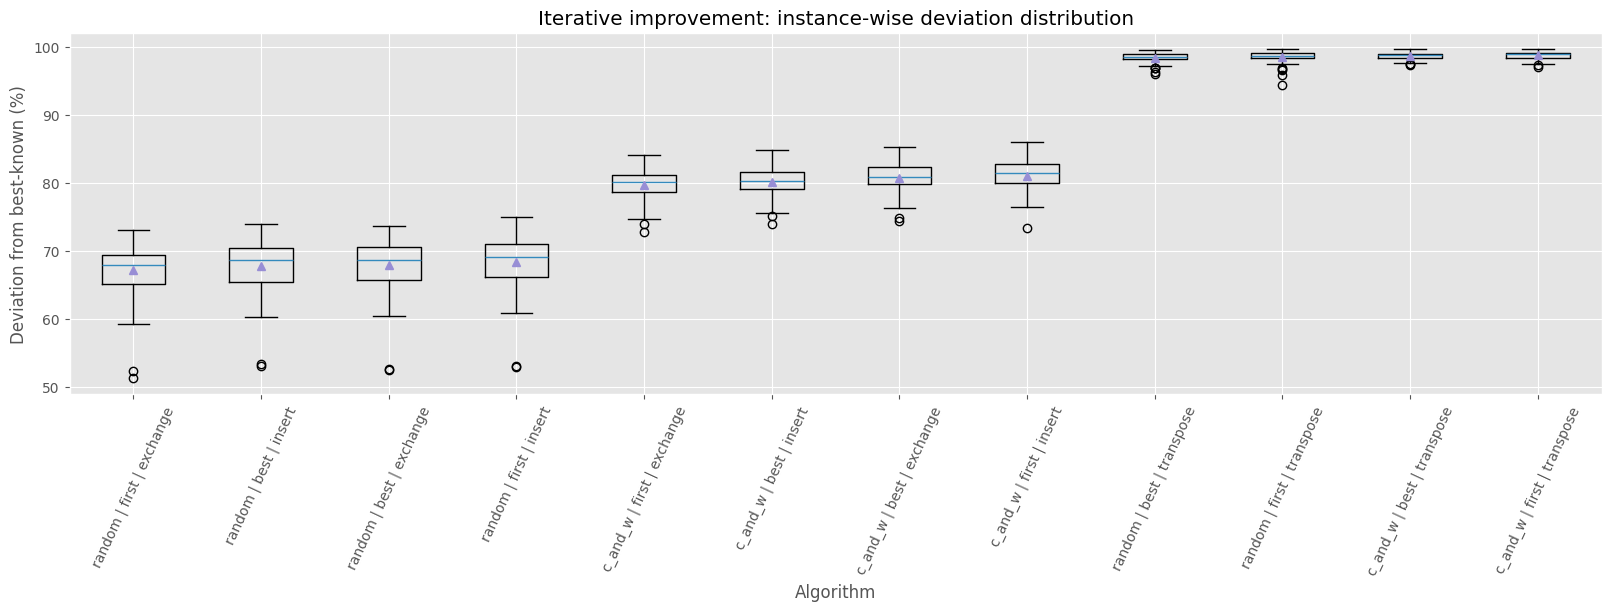

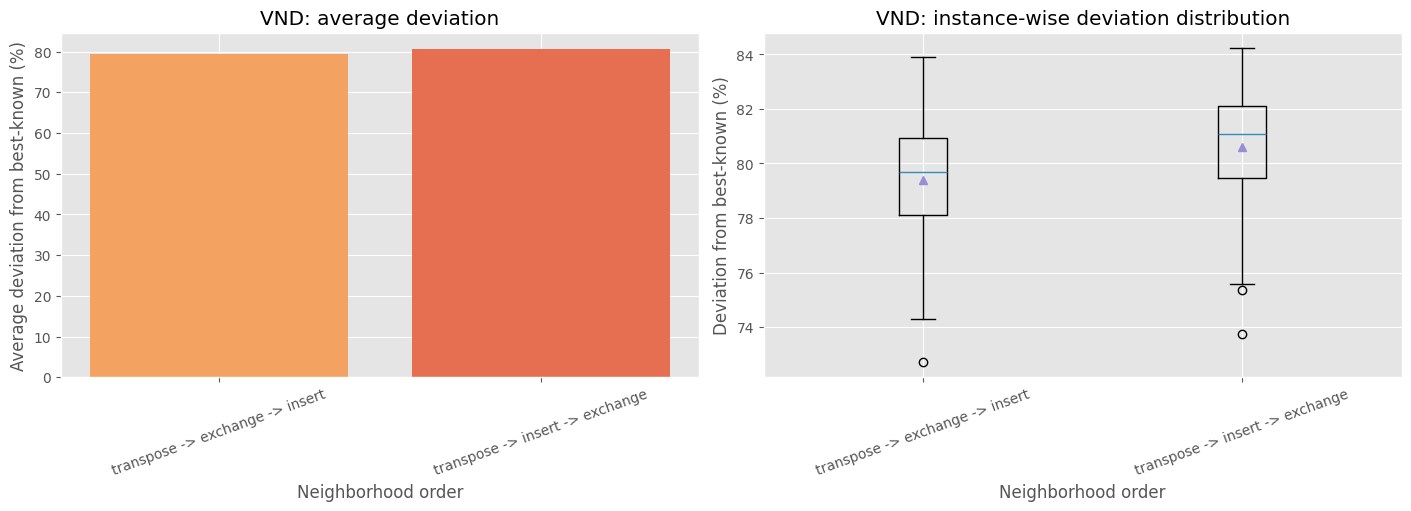

In [8]:
plt.style.use("ggplot")  # emulate R style
PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)

it_plot = it_summary.sort_values("avg_gap_pct")
it_order = it_plot["algorithm"].tolist()

fig_it_summary, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

axes[0].bar(it_plot["algorithm"], it_plot["avg_gap_pct"], color="#2a9d8f")
axes[0].set_title("Iterative improvement: average deviation")
axes[0].set_ylabel("Average deviation from best-known (%)")
axes[0].set_xlabel("Algorithm")
axes[0].tick_params(axis="x", rotation=65)

axes[1].bar(it_plot["algorithm"], it_plot["total_time_s"], color="#457b9d")
axes[1].set_title("Iterative improvement: total time")
axes[1].set_ylabel("Total time across all instances (s)")
axes[1].set_xlabel("Algorithm")
axes[1].tick_params(axis="x", rotation=65)

fig_it_summary.savefig(PATH_TO_FIGS / "it_imp_summary.svg", format="svg")
plt.show()

fig_it_box, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
ax.boxplot(
    [df_it_imp.loc[df_it_imp["algorithm"] == algo, "gap_pct"] for algo in it_order],
    tick_labels=it_order,
    showmeans=True,
)
ax.set_title("Iterative improvement: instance-wise deviation distribution")
ax.set_ylabel("Deviation from best-known (%)")
ax.set_xlabel("Algorithm")
ax.tick_params(axis="x", rotation=65)
fig_it_box.savefig(PATH_TO_FIGS / "it_imp_boxplot.svg", format="svg")
plt.show()

vnd_order = vnd_summary["algorithm"].tolist()
fig_vnd, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar(vnd_summary["algorithm"], vnd_summary["avg_gap_pct"], color=["#f4a261", "#e76f51"])
axes[0].set_title("VND: average deviation")
axes[0].set_ylabel("Average deviation from best-known (%)")
axes[0].set_xlabel("Neighborhood order")
axes[0].tick_params(axis="x", rotation=20)

axes[1].boxplot(
    [df_vnd.loc[df_vnd["algorithm"] == algo, "gap_pct"] for algo in vnd_order],
    tick_labels=vnd_order,
    showmeans=True,
)
axes[1].set_title("VND: instance-wise deviation distribution")
axes[1].set_ylabel("Deviation from best-known (%)")
axes[1].set_xlabel("Neighborhood order")
axes[1].tick_params(axis="x", rotation=20)

fig_vnd.savefig(PATH_TO_FIGS / "vnd_summary.svg", format="svg")
plt.show()
